In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

9


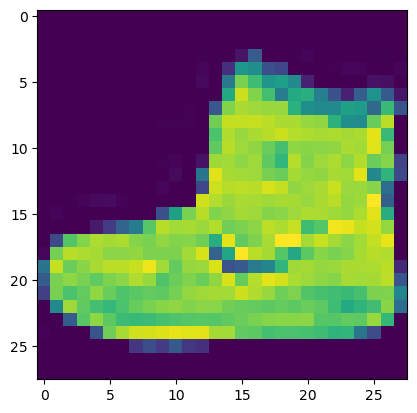

In [5]:
(x_train, y_train), (x_test, y_test) =  fashion_mnist.load_data()
plt.imshow(x_train[0])
print(y_train[0])

In [3]:
print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [7]:
image_train = x_train / 255
image_test = x_test /255
print(image_train[0])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.00392157 0.    

In [8]:
noiseFactor = 0.5
Nimage_train = image_train + noiseFactor * np.random.normal(loc = 0.0, scale = 1, size = (image_train.shape))
Nimage_test = image_test + noiseFactor * np.random.normal(loc = 0.0, scale = 1, size = (image_test.shape))
print(Nimage_train[0])

[[ 0.2727227  -0.3970972   0.0735656   1.00171343 -0.40962438 -0.53950865
   0.8097861  -0.68966045 -0.37147024 -0.10628719 -1.05989232 -0.39227747
   0.27630869 -0.22653019 -0.76514861 -0.47447341 -0.25102786 -0.70544683
  -0.38666016  0.60813637 -0.87550734  0.27367663 -0.14991458  0.36095051
  -0.65990193 -0.88487323 -0.056919    0.30388232]
 [-0.49131848 -1.0872361  -0.51523798 -0.25260422  0.36063494  0.87128881
   0.15645649 -0.46614098 -0.08530855 -0.12378477  0.02219419 -1.1304103
  -0.15838421 -0.32267315  0.11518149  0.31214218 -0.21442633 -0.83052527
  -0.75387534 -0.86061133  0.26849615  0.60152009 -1.08345091  0.71302849
  -0.73877649  0.02860948  0.36685248 -0.39060547]
 [-0.41386801  0.55914812 -1.00092488  0.20929958 -0.63526097 -0.38252942
  -0.89873372 -0.15306931 -1.31362486 -0.00436031 -0.04764217 -0.22549564
   0.91880401 -0.45001262 -0.10799606 -0.31494348 -0.6689282   0.50482881
   0.46815293 -0.14807967  0.01702838  0.2840118  -0.10286927  0.33817074
  -0.228369

In [9]:
Nimage_train = np.clip(Nimage_train, 0, 1)
Nimage_test = np.clip(Nimage_test, 0, 1)
print(Nimage_train)

[[[0.2727227  0.         0.0735656  ... 0.         0.         0.30388232]
  [0.         0.         0.         ... 0.02860948 0.36685248 0.        ]
  [0.         0.55914812 0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.4315334 ]
  [0.312424   0.         0.0578378  ... 0.91351846 0.         0.4773297 ]
  [0.30191296 0.         1.         ... 0.55673849 0.03171496 0.        ]]

 [[0.         0.22133815 0.53814907 ... 0.         0.32087388 0.09947909]
  [0.24962077 1.         0.41303383 ... 0.         0.12016501 0.        ]
  [0.59604482 0.         0.38286994 ... 0.         0.         0.26597056]
  ...
  [0.76140426 0.         0.         ... 0.69227597 0.         0.        ]
  [0.35193196 0.4040481  0.         ... 0.32075064 0.31233574 0.        ]
  [0.51786456 0.         0.         ... 0.         0.01802425 0.        ]]

 [[0.52308039 0.34905567 0.         ... 0.         0.38661697 0.13662703]
  [0.         0.      

In [10]:
from tensorflow.keras import layers, models

In [11]:
inputShape = layers.Input(shape = (28, 28))
encoder = layers.LSTM(128, activation = "relu", return_state = True)(inputShape)
compressedState = encoder[1]
encoderModel = models.Model(inputShape, compressedState)

In [12]:
outputShape = layers.Input(shape = (128, ))
repeatedShape = layers.RepeatVector(28)(outputShape)
decoder = layers.LSTM(128, activation = "relu", return_sequences = True)(repeatedShape)
decompressedState = layers.TimeDistributed(layers.Dense(28, activation = "sigmoid"))(decoder)
decoderModel = models.Model(outputShape, decompressedState)

In [13]:
autoEncoder = models.Model(inputShape, decoderModel(encoderModel(inputShape)))

In [11]:
autoEncoder.compile(optimizer = "adam", loss = "binary_crossentropy")
autoEncoder.fit(Nimage_train, image_train, batch_size = 256, epochs = 10)

Epoch 1/10
102/235 ━━━━━━━━━━━━━━━━━━━━ 32s 244ms/step - loss: 0.5832

KeyboardInterrupt: 

In [ ]:
autoEncoder.save("auto_encoder.h5")

In [14]:
auto_encoder = models.load_model("auto_encoder.h5")

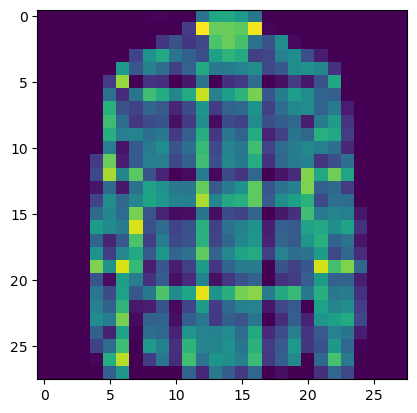

In [15]:
plt.imshow(image_test[7])

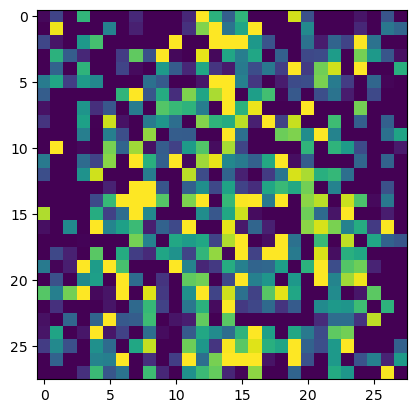

In [16]:
plt.imshow(Nimage_test[7])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


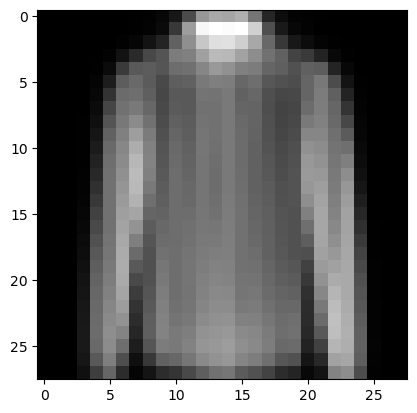

In [17]:
prediction = auto_encoder.predict(Nimage_test)
plt.imshow(prediction[7], cmap = "grey")

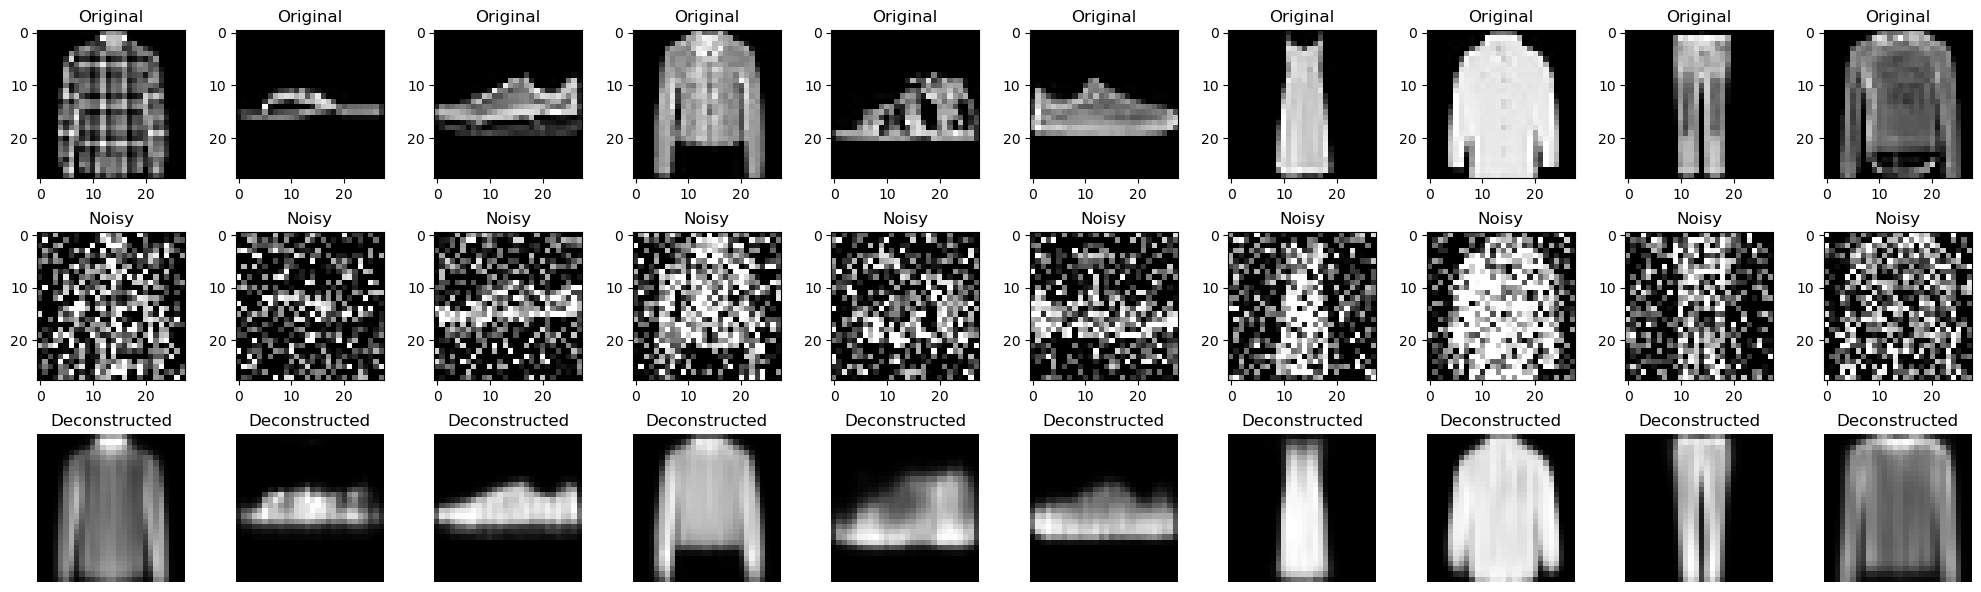

In [18]:
plt.figure(figsize = (20, 6))
plt.subplot(3, 10, 1)
for i in range(10):
    plt.subplot(3, 10, i + 1)
    plt.imshow(image_test[i+7], cmap = "grey")
    plt.title("Original")

    plt.subplot(3, 10, i + 11)
    plt.imshow(Nimage_test[i+7], cmap = "grey")

    plt.title("Noisy")

    plt.subplot(3, 10, i + 21)
    plt.imshow(prediction[i+7], cmap = "grey")

    plt.title("Deconstructed")

    plt.grid(False)
    plt.axis("off")


plt.tight_layout()
plt.show()

Help on Axes in module matplotlib.axes._axes object:

class Axes(matplotlib.axes._base._AxesBase)
 |  Axes(fig, *args, facecolor=None, frameon=True, sharex=None, sharey=None, label='', xscale=None, yscale=None, box_aspect=None, forward_navigation_events='auto', **kwargs)
 |  
 |  An Axes object encapsulates all the elements of an individual (sub-)plot in
 |  a figure.
 |  
 |  It contains most of the (sub-)plot elements: `~.axis.Axis`,
 |  `~.axis.Tick`, `~.lines.Line2D`, `~.text.Text`, `~.patches.Polygon`, etc.,
 |  and sets the coordinate system.
 |  
 |  Like all visible elements in a figure, Axes is an `.Artist` subclass.
 |  
 |  The `Axes` instance supports callbacks through a callbacks attribute which
 |  is a `~.cbook.CallbackRegistry` instance.  The events you can connect to
 |  are 'xlim_changed' and 'ylim_changed' and the callback will be called with
 |  func(*ax*) where *ax* is the `Axes` instance.
 |  
 |  .. note::
 |  
 |      As a user, you do not instantiate Axes direc

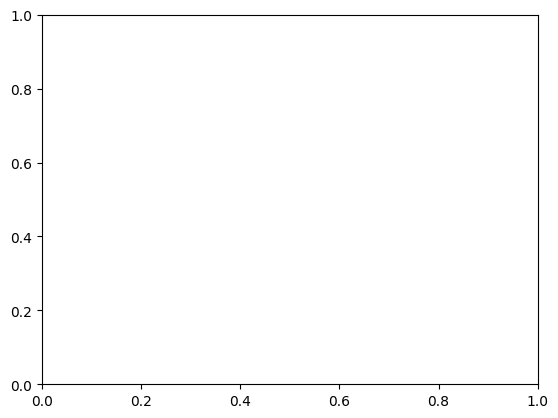